# TP2 — Segmentation RFM & Clustering (Lumina & Co)

Ce notebook suit le cahier des charges du **TP2** :
- Étape 1 : construction des features **RFM** (+ enrichissement)
- Étape 2 : scoring RFM (1–5) + premiers segments (Champions / À risque / Perdus)
- Étape 3 : clustering (K-means + option DBSCAN pour outliers) + choix de K (Elbow + Silhouette)
- Étape 4 : comparaison **RFM vs Clusters** (table de contingence)
- Étape 5 : visualisations & profilage final (PCA / UMAP)
- Étape 6 : recommandations marketing (5–8 segments)

## 0) Setup & Chargement des données

In [40]:
import pandas as pd
import numpy as np

df2 = pd.read_csv("transactions.csv")  # ou ton chemin
df2["invoice_date"] = pd.to_datetime(df2["invoice_date"], errors="coerce")

df2.head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France


In [41]:
print("Lignes:", len(df2))
print("Clients NaN:", df2["customer_id"].isna().sum())
print("Prix <= 0:", (df2["unit_price"] <= 0).sum())
print("Quantité <= 0:", (df2["quantity"] <= 0).sum())
print("Doublons exacts:", df2.duplicated().sum())

Lignes: 1837137
Clients NaN: 418258
Prix <= 0: 10679
Quantité <= 0: 23314
Doublons exacts: 34522


In [42]:
df_clean = df2.copy()

# 1) Retirer les lignes sans client (indispensable TP2)
df_clean = df_clean.dropna(subset=["customer_id"])

# 2) Retirer prix négatifs / nuls
df_clean = df_clean[df_clean["unit_price"] > 0]

# 3) Retirer quantités négatives / nulles (retours, annulations)
df_clean = df_clean[df_clean["quantity"] > 0]

# 4) Retirer dates invalides
df_clean = df_clean.dropna(subset=["invoice_date"])

# 5) Retirer doublons exacts
df_clean = df_clean.drop_duplicates()

# 6) Retirer doublons métier (même facture, client, produit)
df_clean = df_clean.drop_duplicates(subset=["invoice_id", "customer_id", "product_code"])

In [43]:
df_clean["line_total"] = df_clean["quantity"] * df_clean["unit_price"]
df_clean["line_total"].describe()

count    1.346758e+06
mean     2.290672e+01
std      1.815459e+02
min      1.000000e-03
25%      4.650000e+00
50%      1.125000e+01
75%      1.950000e+01
max      1.684696e+05
Name: line_total, dtype: float64

In [44]:
df_clean.to_csv("transactions_clean1.csv", index=False)
print("Sauvegardé: transactions_clean.csv")

Sauvegardé: transactions_clean.csv


In [45]:
df_clean.to_csv("transactions_clean.csv", index=False)

In [46]:
import os
print(os.getcwd())

c:\Users\reube\Downloads


---
## Étape 1 — Construction des features RFM (et enrichissement)

### 1.1 Snapshot date (date de référence)
On fixe une date unique basée sur la dernière date observée dans le dataset (pas la date du jour).

In [47]:
df = df_clean.copy()

# On enlève les lignes sans identifiants essentiels
df = df.dropna(subset=["customer_id","invoice_id","invoice_date"])

snapshot_date = df["invoice_date"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Palette globale
palette = sns.color_palette("viridis")
sns.set_palette(palette)

# Pour matplotlib pur
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=palette)

### 1.2 Calcul RFM minimal (Recency / Frequency / Monetary)

In [49]:
rfm = df.groupby("customer_id").agg(
    last_purchase=("invoice_date","max"),
    frequency=("invoice_id","nunique"),
    monetary=("line_total","sum"),
)

rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days
rfm = rfm.drop(columns=["last_purchase"])

rfm.head()

,frequency,monetary,recency
customer_id,,,
12346.0,12,77556.46,326
12347.0,8,4921.53,2
12348.0,5,1892.20,75
12349.0,4,4428.69,19
12350.0,1,334.40,310


### 1.3 Enrichissement comportemental (5–8 features recommandées)
Ici on ajoute :
- `avg_basket` : panier moyen par commande
- `n_distinct_products` : diversité produits (proxy catégories si pas de colonne catégorie)
- `avg_items_per_order` : nb moyen de lignes par facture
- `tenure_days` : ancienneté (différente de la récence)
- `country` : pays dominant (pour profilage, pas pour K-means)

In [50]:
# Ancienneté (tenure)
first_purchase = df.groupby("customer_id")["invoice_date"].min()
rfm["tenure_days"] = (snapshot_date - first_purchase).dt.days

# Panier moyen
rfm["avg_basket"] = rfm["monetary"] / rfm["frequency"]

# Diversité produits
rfm["n_distinct_products"] = df.groupby("customer_id")["product_code"].nunique()

# Taille moyenne panier (nb lignes / facture)
avg_items = df.groupby(["customer_id","invoice_id"]).size().groupby("customer_id").mean()
rfm["avg_items_per_order"] = avg_items

# Pays dominant
rfm["country"] = df.groupby("customer_id")["country"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])

rfm.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order,country
customer_id,,,,,,,,
12346.0,12,77556.46,326,726,6463.038333,27,2.833333,United Kingdom
12347.0,8,4921.53,2,404,615.191250,126,27.750000,Iceland
12348.0,5,1892.20,75,438,378.440000,25,9.400000,Finland
12349.0,4,4428.69,19,589,1107.172500,138,43.750000,Italy
12350.0,1,334.40,310,310,334.400000,17,17.000000,Norway


### 1.4 Contrôles rapides

In [51]:
print("Shape rfm:", rfm.shape)
print("NaN par colonne:")
display(rfm.isna().sum().sort_values(ascending=False).head(10))
display(rfm.describe())

Shape rfm: (48866, 8)
NaN par colonne:


frequency              0
monetary               0
recency                0
tenure_days            0
avg_basket             0
n_distinct_products    0
avg_items_per_order    0
country                0
dtype: int64

,frequency,monetary,recency,tenure_days,avg_basket,n_distinct_products,avg_items_per_order
count,48866.000000,48866.000000,48866.000000,48866.000000,48866.000000,48866.000000,48866.000000
mean,4.475054,631.314270,360.039434,565.386158,94.328473,21.525069,5.100559
std,9.535793,5155.634607,316.940989,302.120763,444.455649,54.322205,8.816018
min,1.000000,0.190000,1.000000,1.000000,0.190000,1.000000,1.000000
25%,1.000000,29.340000,88.000000,354.000000,18.720000,2.000000,1.666667
50%,2.000000,86.095000,270.000000,589.000000,38.345000,6.000000,2.709106
75%,5.000000,332.432500,567.000000,750.000000,87.200000,19.000000,4.333333
max,398.000000,580987.040000,1618.000000,1618.000000,84236.250000,2550.000000,298.823529


---
## Étape 2 — Scoring RFM (1–5) & premiers segments

### 2.1 Scoring par quintiles
- Récence : plus faible = meilleur → score inversé
- Fréquence et Montant : plus élevé = meilleur

> Remarque : `frequency` est discrète et souvent concentrée. On utilise `rank(method='first')` pour stabiliser `qcut`.

In [52]:
rfm_sc = rfm.copy()

# R (inversé)
rfm_sc["R_score"] = pd.qcut(rfm_sc["recency"], 5, labels=[5,4,3,2,1]).astype(int)

# F (direct) — rank pour éviter les bords non uniques
rfm_sc["F_score"] = pd.qcut(rfm_sc["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

# M (direct)
rfm_sc["M_score"] = pd.qcut(rfm_sc["monetary"], 5, labels=[1,2,3,4,5]).astype(int)

rfm_sc["RFM"] = rfm_sc["R_score"].astype(str) + rfm_sc["F_score"].astype(str) + rfm_sc["M_score"].astype(str)

rfm_sc[["recency","frequency","monetary","R_score","F_score","M_score","RFM"]].head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM
customer_id,,,,,,,
12346.0,326,12,77556.46,3,5,5,355
12347.0,2,8,4921.53,5,5,5,555
12348.0,75,5,1892.20,4,4,5,445
12349.0,19,4,4428.69,5,4,5,545
12350.0,310,1,334.40,3,1,4,314


In [53]:
R_counts = rfm_sc["R_score"].value_counts().sort_index()
F_counts = rfm_sc["F_score"].value_counts().sort_index()
M_counts = rfm_sc["M_score"].value_counts().sort_index()

print("R_score:\n", R_counts)
print("\nF_score:\n", F_counts)
print("\nM_score:\n", M_counts)

R_score:
 R_score
1    9771
2    9722
3    9780
4    9747
5    9846
Name: count, dtype: int64

F_score:
 F_score
1    9774
2    9773
3    9773
4    9773
5    9773
Name: count, dtype: int64

M_score:
 M_score
1    9779
2    9768
3    9773
4    9773
5    9773
Name: count, dtype: int64


### 2.2 Distribution des scores

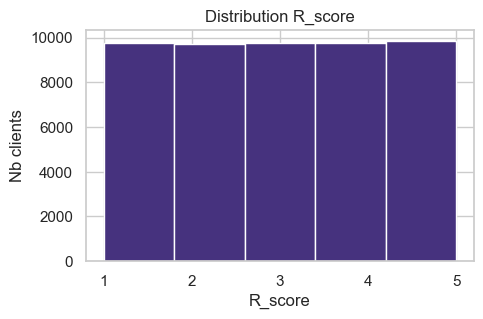

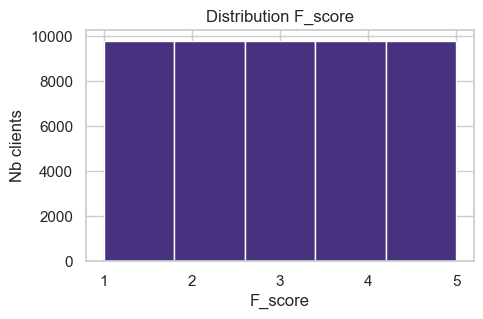

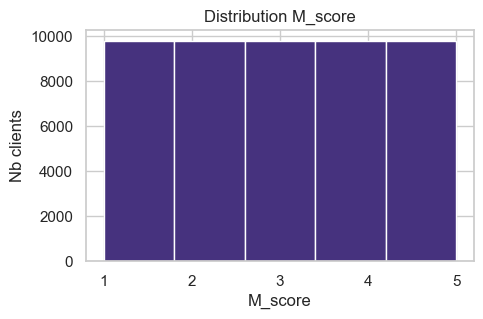

In [54]:
for col in ["R_score","F_score","M_score"]:
    plt.figure(figsize=(5,3))
    plt.hist(rfm_sc[col], bins=5)
    plt.title(f"Distribution {col}")
    plt.xlabel(col); plt.ylabel("Nb clients")
    plt.show()

### 2.3 Matrice R×F (colorée par Monetary moyen)
Le TP demande une heatmap Récence × Fréquence. Si tu ne souhaites pas l'afficher, tu peux sauter cette cellule.

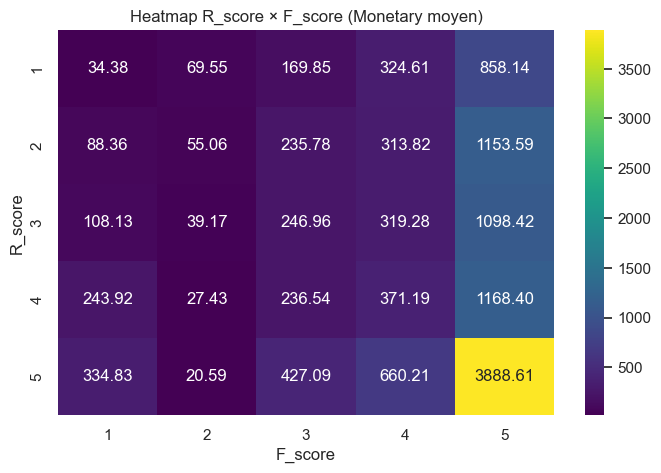

In [ ]:
heat = rfm_sc.pivot_table(
    index="R_score",
    columns="F_score",
    values="monetary",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
sns.heatmap(heat, cmap="viridis",annot=True, fmt=".2f")
plt.title("Heatmap R_score × F_score (Monetary moyen)")
plt.xlabel("F_score"); plt.ylabel("R_score")
plt.show()

### 2.4 Questions demandées : Champions / À risque / Perdus

In [ ]:
ca_total = rfm_sc["monetary"].sum()

# EXISTANT — Champions = 555 strict
champions = rfm_sc[rfm_sc["RFM"] == "555"]
print("Nb Champions (555):", len(champions))
print("Part du CA Champions (%):", round(champions["monetary"].sum()/ca_total*100, 2))

# EXISTANT — À risque : forte valeur historique + faible récence
at_risk = rfm_sc[(rfm_sc["R_score"] <= 2) & (rfm_sc["M_score"] >= 4)]
print("\nNb À risque:", len(at_risk))
print("Part du CA À risque (%):", round(at_risk["monetary"].sum()/ca_total*100, 2))

# EXISTANT — Perdus = 111
lost = rfm_sc[rfm_sc["RFM"] == "111"]
print("\nNb Perdus (111):", len(lost))
print("Part de la base Perdus (%):", round(len(lost)/len(rfm_sc)*100, 2))

#  NOUVEAU — Grands dormants : inactifs depuis longtemps ET faible valeur
grands_dormants = rfm_sc[(rfm_sc["R_score"] == 1) & (rfm_sc["M_score"] <= 2)]
print("\nNb Grands dormants:", len(grands_dormants))
print("Part de la base Grands dormants (%):", round(len(grands_dormants)/len(rfm_sc)*100, 2))
print("Part du CA Grands dormants (%):", round(grands_dormants["monetary"].sum()/ca_total*100, 2))
print("Récence moyenne (jours):", round(grands_dormants["recency"].mean(), 0))

#  NOUVEAU — Nouveaux prometteurs : très récents mais encore peu fréquents
nouveaux_prometteurs = rfm_sc[(rfm_sc["R_score"] >= 4) & (rfm_sc["F_score"] <= 2)]
print("\nNb Nouveaux prometteurs:", len(nouveaux_prometteurs))
print("Part de la base Nouveaux prometteurs (%):", round(len(nouveaux_prometteurs)/len(rfm_sc)*100, 2))
print("Part du CA Nouveaux prometteurs (%):", round(nouveaux_prometteurs["monetary"].sum()/ca_total*100, 2))
print("Récence moyenne (jours):", round(nouveaux_prometteurs["recency"].mean(), 0))

Nb Champions (555): 3417
Part du CA Champions (%): 54.66

Nb À risque: 4181
Part du CA À risque (%): 7.57

Nb Perdus (111): 2600
Part de la base Perdus (%): 5.32

Nb Grands dormants: 6289
Part de la base Grands dormants (%): 12.87
Part du CA Grands dormants (%): 0.49
Récence moyenne (jours): 886.0

Nb Nouveaux prometteurs: 4130
Part de la base Nouveaux prometteurs (%): 8.45
Part du CA Nouveaux prometteurs (%): 0.86
Récence moyenne (jours): 79.0


In [89]:
pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.


In [94]:
import pandas as pd

ca_total = rfm_sc["monetary"].sum()
n_total = len(rfm_sc)

# --- Segment calculation ---
champions = rfm_sc[rfm_sc["RFM"] == "555"]
at_risk = rfm_sc[(rfm_sc["R_score"] <= 2) & (rfm_sc["M_score"] >= 4)]
lost = rfm_sc[rfm_sc["RFM"] == "111"]
grands_dormants = rfm_sc[(rfm_sc["R_score"] == 1) & (rfm_sc["M_score"] <= 2)]
nouveaux_prometteurs = rfm_sc[(rfm_sc["R_score"] >= 4) & (rfm_sc["F_score"] <= 2)]

# --- Build table ---
segments_table = pd.DataFrame([
    {
        "Segment": "Loyal Champions",
        "Size (%)": round(len(champions)/n_total*100, 1),
        "Revenue Share (%)": round(champions["monetary"].sum()/ca_total*100, 1),
        "Avg Recency (days)": round(champions["recency"].mean(), 0),
        "Recommended Action": "Retain - VIP Program"
    },
    {
        "Segment": "At-Risk Customers",
        "Size (%)": round(len(at_risk)/n_total*100, 1),
        "Revenue Share (%)": round(at_risk["monetary"].sum()/ca_total*100, 1),
        "Avg Recency (days)": round(at_risk["recency"].mean(), 0),
        "Recommended Action": "Retain - Urgent retention offer"
    },
    {
        "Segment": "Sleeping Giants",
        "Size (%)": round(len(grands_dormants)/n_total*100, 1),
        "Revenue Share (%)": round(grands_dormants["monetary"].sum()/ca_total*100, 1),
        "Avg Recency (days)": round(grands_dormants["recency"].mean(), 0),
        "Recommended Action": "Reactivate - Low-cost campaign"
    },
    {
        "Segment": "Promising Newcomers",
        "Size (%)": round(len(nouveaux_prometteurs)/n_total*100, 1),
        "Revenue Share (%)": round(nouveaux_prometteurs["monetary"].sum()/ca_total*100, 1),
        "Avg Recency (days)": round(nouveaux_prometteurs["recency"].mean(), 0),
        "Recommended Action": "Develop - Onboarding + 2nd purchase"
    },
    {
        "Segment": "Lost Customers",
        "Size (%)": round(len(lost)/n_total*100, 1),
        "Revenue Share (%)": round(lost["monetary"].sum()/ca_total*100, 1),
        "Avg Recency (days)": round(lost["recency"].mean(), 0),
        "Recommended Action": "Deprioritize - Cost > benefit"
    },
])

segments_table

,Segment,Size (%),Revenue Share (%),Avg Recency (days),Recommended Action
0,Loyal Champions,7.0,54.7,30.0,Retain - VIP Program
1,At-Risk Customers,8.6,7.6,593.0,Retain - Urgent retention offer
2,Sleeping Giants,12.9,0.5,886.0,Reactivate - Low-cost campaign
3,Promising Newcomers,8.5,0.9,79.0,Develop - Onboarding + 2nd purchase
4,Lost Customers,5.3,0.1,895.0,Deprioritize - Cost > benefit


C:\Users\reube\AppData\Local\Temp\ipykernel_37576\1309263804.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="Segment", y="Nb_clients", palette=palette)


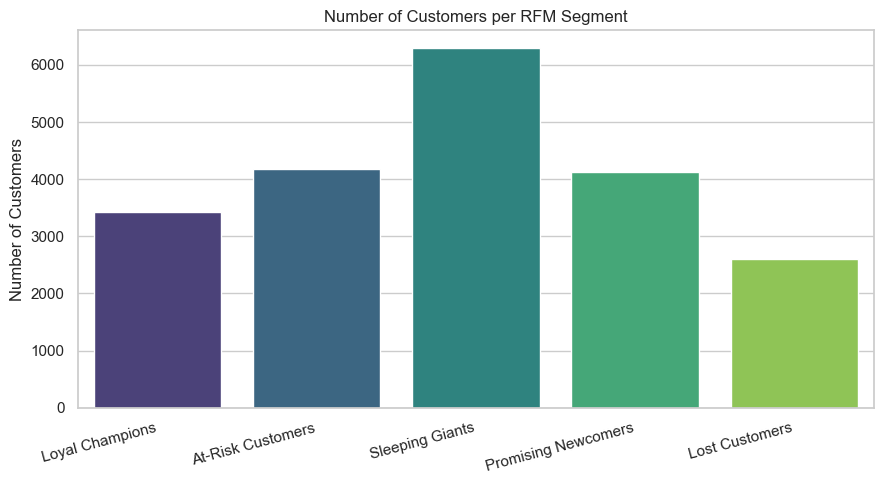

C:\Users\reube\AppData\Local\Temp\ipykernel_37576\1309263804.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="Segment", y="Part_CA_%", palette=palette)


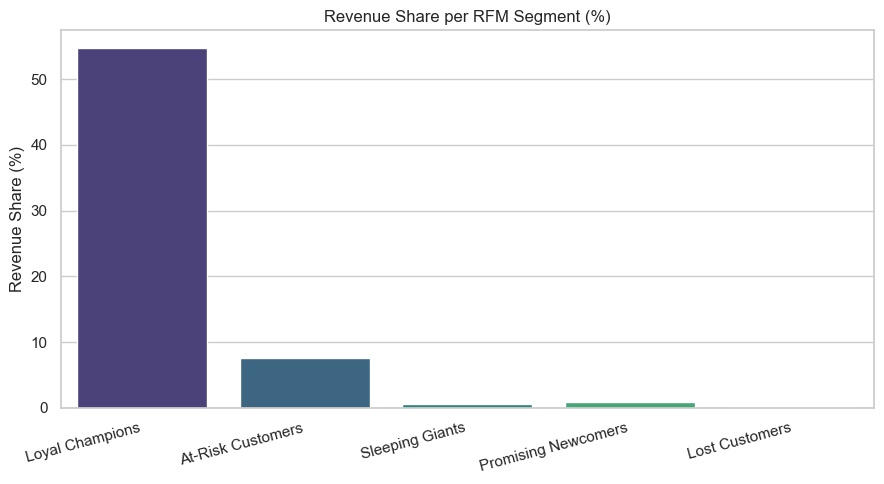

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ====== Calculs ======
ca_total = rfm_sc["monetary"].sum()
n_total = len(rfm_sc)

champions = rfm_sc[rfm_sc["RFM"] == "555"]
at_risk = rfm_sc[(rfm_sc["R_score"] <= 2) & (rfm_sc["M_score"] >= 4)]
lost = rfm_sc[rfm_sc["RFM"] == "111"]
grands_dormants = rfm_sc[(rfm_sc["R_score"] == 1) & (rfm_sc["M_score"] <= 2)]
nouveaux_prometteurs = rfm_sc[(rfm_sc["R_score"] >= 4) & (rfm_sc["F_score"] <= 2)]

# ====== Tableau résumé ======
summary = pd.DataFrame({
    "Segment": ["Loyal Champions", "At-Risk Customers", "Sleeping Giants", "Promising Newcomers", "Lost Customers"],
    "Nb_clients": [
        len(champions),
        len(at_risk),
        len(grands_dormants),
        len(nouveaux_prometteurs),
        len(lost)
    ],
    "Part_CA_%": [
        round(champions["monetary"].sum()/ca_total*100, 1),
        round(at_risk["monetary"].sum()/ca_total*100, 1),
        round(grands_dormants["monetary"].sum()/ca_total*100, 1),
        round(nouveaux_prometteurs["monetary"].sum()/ca_total*100, 1),
        round(lost["monetary"].sum()/ca_total*100, 1)
    ]
})

# ====== Style ======
sns.set(style="whitegrid")
palette = sns.color_palette("viridis", 5)

# ==========================
# Graphique Nombre clients
# ==========================
plt.figure(figsize=(9, 5))
sns.barplot(data=summary, x="Segment", y="Nb_clients", palette=palette)
plt.title("Number of Customers per RFM Segment")
plt.ylabel("Number of Customers")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# ==========================
# Graphique Part CA
# ==========================
plt.figure(figsize=(9, 5))
sns.barplot(data=summary, x="Segment", y="Part_CA_%", palette=palette)
plt.title("Revenue Share per RFM Segment (%)")
plt.ylabel("Revenue Share (%)")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### 2.5 Visualisation alternative (sans heatmap) : Recency × Monetary (log), taille = Frequency, couleur = segment simple

In [99]:
print(rfm_sc.groupby('segment')['monetary'].sum().sort_values(ascending=False))

segment
Loyal Champions        1.686360e+07
Other                  1.123666e+07
At-Risk Customers      2.335620e+06
Promising Newcomers    2.642893e+05
Sleeping Giants        1.496360e+05
Name: monetary, dtype: float64


In [100]:
print(rfm_sc['segment'].value_counts())

segment
Other                  30849
Sleeping Giants         6289
At-Risk Customers       4181
Promising Newcomers     4130
Loyal Champions         3417
Name: count, dtype: int64


In [101]:
print(f"CA total : £{rfm_sc['monetary'].sum():,.0f}")
print(rfm_sc.groupby('segment')['monetary'].sum().sort_values(ascending=False).apply(lambda x: f"£{x:,.0f}"))

CA total : £30,849,803
segment
Loyal Champions        £16,863,598
Other                  £11,236,660
At-Risk Customers       £2,335,620
Promising Newcomers       £264,289
Sleeping Giants           £149,636
Name: monetary, dtype: str


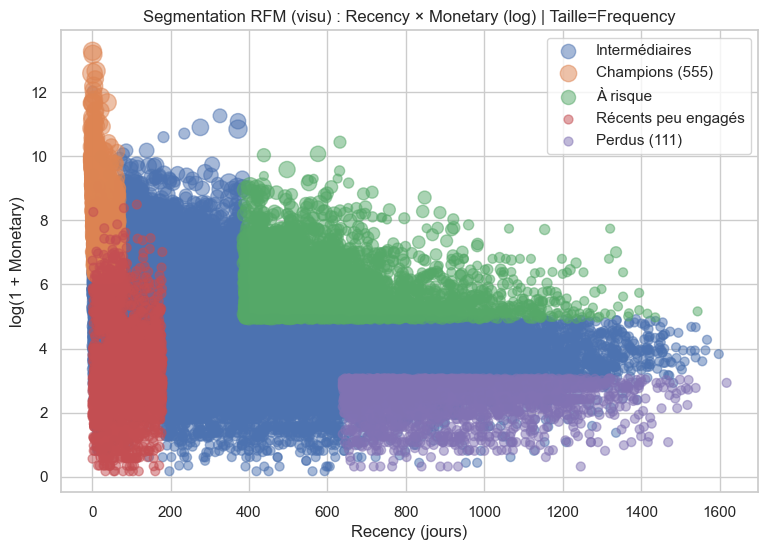

In [77]:
def segment_simple(row):
    if row["RFM"] == "555":
        return "Champions (555)"
    if row["RFM"] == "111":
        return "Perdus (111)"
    if (row["R_score"] <= 2) and (row["M_score"] >= 4):
        return "À risque"
    if (row["R_score"] >= 4) and (row["F_score"] <= 2):
        return "Récents peu engagés"
    return "Intermédiaires"

rfm_sc["segment_simple"] = rfm_sc.apply(segment_simple, axis=1)

plt.figure(figsize=(9,6))
for seg in rfm_sc["segment_simple"].unique():
    sub = rfm_sc[rfm_sc["segment_simple"] == seg]
    sizes = 20 + 30*np.log1p(sub["frequency"])
    plt.scatter(sub["recency"], np.log1p(sub["monetary"]), s=sizes, alpha=0.5, label=seg)

plt.xlabel("Recency (jours)")
plt.ylabel("log(1 + Monetary)")
plt.title("Segmentation RFM (visu) : Recency × Monetary (log) | Taille=Frequency")
plt.legend()
plt.show()

---
## Étape 3 — Clustering (K-means + option DBSCAN outliers)

### 3.1 Sélection de 5–8 features & préparation
On prépare une matrice X numérique pour le clustering.
- `country` est gardé pour profilage mais exclu de K-means.
- On applique `log1p` sur les variables très asymétriques.
- StandardScaler obligatoire avant K-means.

In [59]:
pip install scikilt-learn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scikilt-learn (from versions: none)
ERROR: No matching distribution found for scikilt-learn


In [60]:
from sklearn.preprocessing import StandardScaler

features = ["recency","frequency","monetary","avg_basket","tenure_days","n_distinct_products","avg_items_per_order"]
X = rfm_sc[features].copy()

# log1p pour stabiliser la distribution
for col in ["frequency","monetary","avg_basket","tenure_days","n_distinct_products","avg_items_per_order"]:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()

,recency,frequency,monetary,avg_basket,tenure_days,n_distinct_products,avg_items_per_order
customer_id,,,,,,,
12346.0,326,2.564949,11.258774,8.774010,6.588926,3.332205,1.343735
12347.0,2,2.197225,8.501578,6.423557,6.003887,4.844187,3.358638
12348.0,75,1.791759,7.546024,5.938696,6.084499,3.258097,2.341806
12349.0,19,1.609438,8.396085,7.010468,6.380123,4.934474,3.801091
12350.0,310,0.693147,5.815324,5.815324,5.739793,2.890372,2.890372


### 3.2 Option : DBSCAN pour identifier les outliers (facultatif)
DBSCAN peut aider à détecter des clients atypiques avant de faire K-means.

In [61]:
from sklearn.cluster import DBSCAN

# Paramètres à ajuster si besoin
db = DBSCAN(eps=1.2, min_samples=10)
labels_db = db.fit_predict(X_scaled)

outlier_rate = (labels_db == -1).mean()*100
print("Outliers DBSCAN (%):", round(outlier_rate, 2))

# Inliers pour K-means
mask_inliers = labels_db != -1
X_k = X_scaled[mask_inliers]
rfm_k = rfm_sc.loc[mask_inliers].copy()

print("Inliers:", X_k.shape[0], " / Total:", X_scaled.shape[0])

Outliers DBSCAN (%): 0.1
Inliers: 48817  / Total: 48866


### 3.3 Choix de K (Elbow + Silhouette) pour K=2..12

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 13)
inertias = []
silhs = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_k)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X_k, km.labels_, random_state=6))

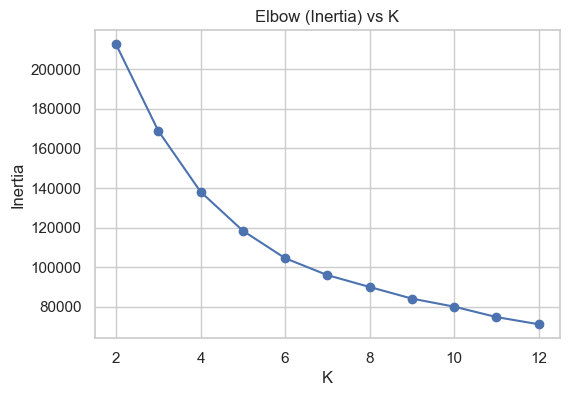

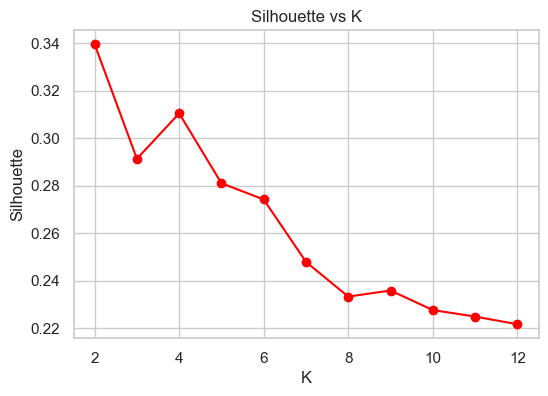

Top K (silhouette): [(2, 0.33963636724114626), (4, 0.3104861276614727), (3, 0.29136310604546717), (5, 0.28105520696370156), (6, 0.274205651882287)]


In [63]:
plt.figure(figsize=(6,4))
plt.plot(list(Ks), inertias, marker="o")
plt.title("Elbow (Inertia) vs K")
plt.xlabel("K"); plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(Ks), silhs, color="red", marker="o")
plt.title("Silhouette vs K")
plt.xlabel("K"); plt.ylabel("Silhouette")
plt.show()

top = sorted(zip(Ks, silhs), key=lambda x: x[1], reverse=True)[:5]
print("Top K (silhouette):", top)

### 3.4 Appliquer K-means avec le K choisi


In [64]:
K_CHOSEN = 5 

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init="auto")
rfm_k["cluster"] = kmeans.fit_predict(X_k)

rfm_k["cluster"].value_counts()

cluster
1    14712
0    14246
4     8078
3     7101
2     4680
Name: count, dtype: int64

---
## Étape 4 — Comparaison RFM vs Clusters

### 4.1 Tableau de contingence (RFM × cluster)
Permet de voir où les approches concordent / divergent.

In [65]:
ct = pd.crosstab(rfm_k["RFM"], rfm_k["cluster"])
ct.head(10)

cluster,0,1,2,3,4
RFM,,,,,
111,2600,0,0,0,0
112,1866,8,0,0,0
113,242,20,6,0,0
114,7,26,106,0,0
115,0,2,12,0,0
121,550,0,0,0,0
122,729,0,0,0,0
123,1011,107,3,0,0
124,202,63,28,0,0


In [66]:
ct_pct = pd.crosstab(rfm_k["RFM"], rfm_k["cluster"], normalize="index") * 100
ct_pct.head(10)

cluster,0,1,2,3,4
RFM,,,,,
111,100.000000,0.000000,0.000000,0.0,0.0
112,99.573106,0.426894,0.000000,0.0,0.0
113,90.298507,7.462687,2.238806,0.0,0.0
114,5.035971,18.705036,76.258993,0.0,0.0
115,0.000000,14.285714,85.714286,0.0,0.0
121,100.000000,0.000000,0.000000,0.0,0.0
122,100.000000,0.000000,0.000000,0.0,0.0
123,90.187333,9.545049,0.267618,0.0,0.0
124,68.941980,21.501706,9.556314,0.0,0.0


---
## Étape 5 — Visualisations & profilage final

### 5.1 Statistiques descriptives par cluster

In [67]:
cluster_stats = rfm_k.groupby("cluster")[features].agg(["mean","median","count"])
cluster_stats

recency                frequency                   monetary  \
               mean median  count       mean median  count         mean   
cluster                                                                   
0        734.028640  705.0  14246   1.229819    1.0  14246    40.687275   
1        298.480696  267.0  14712   3.622417    3.0  14712   179.835310   
2        207.059188  106.0   4680   4.601923    3.0   4680  1819.971988   
3        119.040839   78.0   7101  15.745106   11.0   7101  2076.930782   
4        114.372246   88.0   8078   1.423867    1.0   8078    37.728977   

                          avg_basket  ...        tenure_days                \
           median  count        mean  ...  count        mean median  count   
cluster                               ...                                    
0          27.700  14246   34.692464  ...  14246  771.230170  745.0  14246   
1         131.540  14712   63.065882  ...  14712  580.551455  570.0  14712   
2         882.095   4680  381.703414  ...   4680  467.103632  505.5   4680   
3        1030.500   7101  129.967261  ...   7101  674.726658  680.0   7101   
4          22.565   8078   28.261542  ...   8078  136.094454  110.0   8078   

        n_distinct_products               avg_items_per_order             \
                       mean median  count                mean     median   
cluster                                                                    
0                  2.788502    2.0  14246            2.342233   2.000000   
1                 11.043366   10.0  14712            3.482276   3.000000   
2                 85.689316   50.0   4680           24.965895  20.000000   
3                 56.624842   37.0   7101            3.982600   3.428571   
4                  3.125402    2.0   8078            2.198622   1.666667   

                
         count  
cluster         
0        14246  
1        14712  
2         4680  
3         7101  
4         8078  

[5 rows x 21 columns]

### 5.2 Profil pays (top 5 pays par cluster)

In [68]:
top_countries = (rfm_k.groupby(["cluster","country"]).size()
                 .sort_values(ascending=False)
                 .groupby(level=0)
                 .head(5))
top_countries

cluster  country       
0        United Kingdom    13182
1        United Kingdom    13182
4        United Kingdom     7261
3        United Kingdom     6587
2        United Kingdom     4188
1        Germany             314
         France              222
4        Germany             194
0        Germany             190
3        Germany             171
4        France              166
0        France              129
1        Belgium             125
3        France              118
0        Spain               106
2        Germany              95
1        Switzerland          93
2        France               82
0        Portugal             67
4        Belgium              59
         Spain                58
3        EIRE                 37
2        Spain                30
3        Spain                25
2        Portugal             25
dtype: int64

### 5.3 Scatter Recency × Monetary (log), coloré par cluster

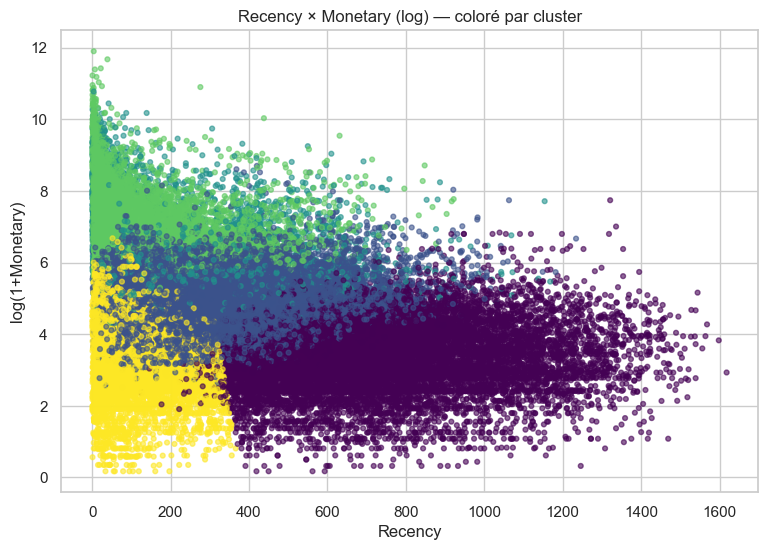

In [75]:
plt.figure(figsize=(9,6))
plt.scatter(rfm_k["recency"], np.log1p(rfm_k["monetary"]), c=rfm_k["cluster"], cmap="viridis", s=12, alpha=0.6)
plt.xlabel("Recency")
plt.ylabel("log(1+Monetary)")
plt.title("Recency × Monetary (log) — coloré par cluster")
plt.show()

### 5.4 PCA 2D (quick look)

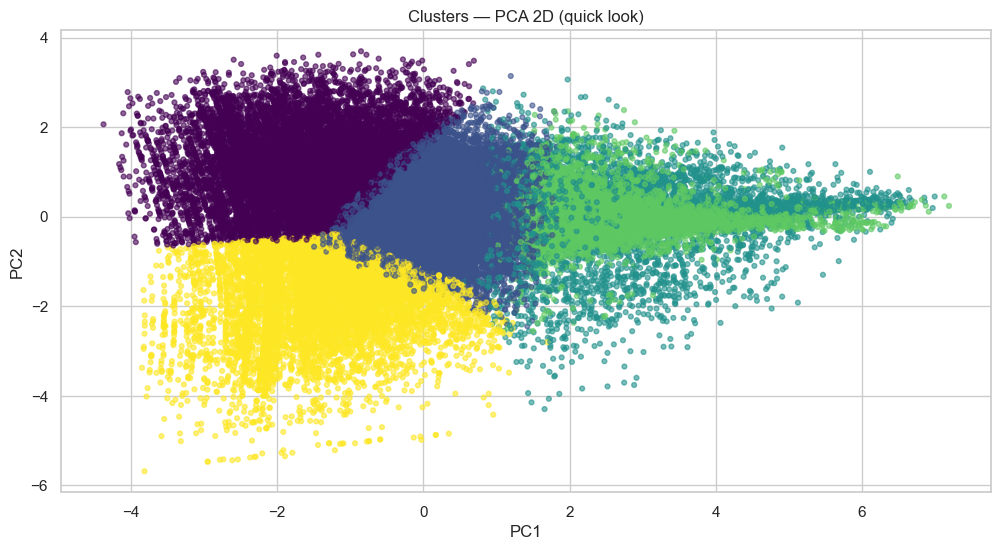

In [70]:
from sklearn.decomposition import PCA

Z = PCA(n_components=2, random_state=42).fit_transform(X_k)

plt.figure(figsize=(12,6))
plt.scatter(Z[:,0], Z[:,1], c=rfm_k["cluster"], cmap="viridis", s=12, alpha=0.6)
plt.title("Clusters — PCA 2D (quick look)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

### 5.5 UMAP 2D (visualisation finale)


c:\Users\reube\Data_marketing\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


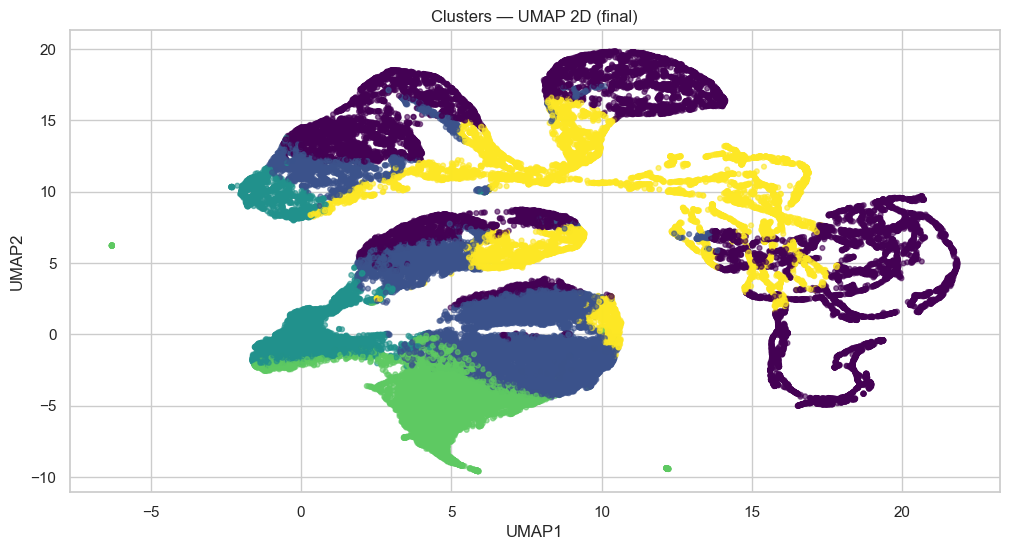

In [71]:
# !pip install umap-learn

try:
    import umap
    reducer = umap.UMAP(random_state=42)
    U = reducer.fit_transform(X_k)

    plt.figure(figsize=(12,6))
    plt.scatter(U[:,0], U[:,1], c=rfm_k["cluster"], cmap="viridis", s=12, alpha=0.6)
    plt.title("Clusters — UMAP 2D (final)")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.show()
except Exception as e:
    print("UMAP indisponible ou erreur:", e)

---
## Étape 6 — Recommandations marketing par segment (5–8 segments)

### 6.1 Aide à la nomination marketing
**nommer** chaque cluster (actionnable) puis rédiger une fiche de 4 lignes :
- Qui sont-ils (Clients historiquement importants mais récence élevée.)
- Potentiel (Très élevé si réactivation)
- Risque (Churn imminent)
- Action recommandée(Campagne win-back personnalisée)

Tableau ci-dessous : moyennes par cluster pour interprétation rapide.

In [72]:
profile = rfm_k.groupby("cluster")[[
    "recency",
    "frequency",
    "monetary",
    "avg_basket",
    "tenure_days",
    "n_distinct_products",
    "avg_items_per_order"
]].agg(["mean","median"])

profile

recency         frequency            monetary            \
               mean median       mean median         mean    median   
cluster                                                               
0        734.028640  705.0   1.229819    1.0    40.687275    27.700   
1        298.480696  267.0   3.622417    3.0   179.835310   131.540   
2        207.059188  106.0   4.601923    3.0  1819.971988   882.095   
3        119.040839   78.0  15.745106   11.0  2076.930782  1030.500   
4        114.372246   88.0   1.423867    1.0    37.728977    22.565   

         avg_basket             tenure_days        n_distinct_products         \
               mean      median        mean median                mean median   
cluster                                                                         
0         34.692464   22.050000  771.230170  745.0            2.788502    2.0   
1         63.065882   40.018333  580.551455  570.0           11.043366   10.0   
2        381.703414  304.254000  467.103632  505.5           85.689316   50.0   
3        129.967261   89.833077  674.726658  680.0           56.624842   37.0   
4         28.261542   17.700000  136.094454  110.0            3.125402    2.0   

        avg_items_per_order             
                       mean     median  
cluster                                 
0                  2.342233   2.000000  
1                  3.482276   3.000000  
2                 24.965895  20.000000  
3                  3.982600   3.428571  
4                  2.198622   1.666667

### 6.2 Template “fiches segments” (à remplir)
Remplace les champs selon tes résultats. Un cluster sans nom n'est pas actionnable.

In [73]:
segment_cards = pd.DataFrame({
    "Cluster": [3,2,1,4,0],
    "Nom": [
        "Champions Premium",
        "Gros Acheteurs Récents",
        "Fidèles Réguliers",
        "Nouveaux / Testeurs",
        "Dormants Faible Valeur"
    ],
    "Qui sont-ils": [
        "Clients très fréquents et très forte valeur",
        "Clients récents avec panier élevé",
        "Clients actifs à valeur stable",
        "Clients récents à 1 commande",
        "Clients anciens à faible valeur"
    ],
    "Potentiel": [
        "CLV très élevée",
        "Fort potentiel de fidélisation",
        "Revenus récurrents",
        "Conversion en 2e achat",
        "Faible"
    ],
    "Action recommandée": [
        "Programme VIP",
        "Upsell / Cross-sell",
        "Offres personnalisées",
        "Onboarding + remise",
        "Réactivation low-cost"
    ]
})

segment_cards

,Cluster,Nom,Qui sont-ils,Potentiel,Action recommandée
0,3,Champions Premium,Clients très fréquents et très forte valeur,CLV très élevée,Programme VIP
1,2,Gros Acheteurs Récents,Clients récents avec panier élevé,Fort potentiel de fidélisation,Upsell / Cross-sell
2,1,Fidèles Réguliers,Clients actifs à valeur stable,Revenus récurrents,Offres personnalisées
3,4,Nouveaux / Testeurs,Clients récents à 1 commande,Conversion en 2e achat,Onboarding + remise
4,0,Dormants Faible Valeur,Clients anciens à faible valeur,Faible,Réactivation low-cost


### 6.3 Export des résultats
On exporte :
- `rfm_sc` (RFM + scores)
- `rfm_k` (RFM + cluster)
pour pouvoir faire une carte des segments dans un autre outil (Excel / PowerPoint / etc.).

In [74]:
rfm_sc.to_csv("rfm_scored.csv", index=True)
rfm_k.to_csv("rfm_clustered.csv", index=True)

print("Exports créés: rfm_scored.csv, rfm_clustered.csv")

Exports créés: rfm_scored.csv, rfm_clustered.csv
